Notebook 2: MASW pseudo-2D
===============================================================================

In [1]:
# importazione di librerie e moduli
import os
import sys
import copy
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(1, '../swa')

from geometry import *
from utils import *
from _stream import SeismicStream
from _curve import Curve
from _combineCurves import CombineCurves

#import matplotlib
#matplotlib.use('Qt5Agg')

In [2]:
# set dei percorsi
method = 'fdbf'
version = 'manual'
prj_dir = '../data/syn_data'
path2raw = os.path.join(prj_dir,'raw')
path2geom = f'{prj_dir}/geometry_test.csv' # Directory containing the geometry file
path2fk = f'{prj_dir}/proc/fk_filter/' # Directory containing the FK filter file
path2disp = f'{prj_dir}/proc/dc_pick/MASW2D/{method}_{version}/picks/'
path2cmb = f'{prj_dir}/proc/dc_pick/MASW2D/{method}_{version}/cmb/'
path2plot = 'figures/'
ext = '.sgy'  # Shot file extension

safe_makedirs(path2plot)

# List of directories to create
directories = [path2raw, path2geom, path2fk, path2disp, path2cmb, path2plot]
def create_dir(dir_list):
    for directory in dir_list:
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"📁 Directory created: {directory}")
create_dir(directories)

In [3]:
# dizionario con le impostazioni di processing e plot
fmin = 5
fmax = 50

settings = create_settings_dict(trafo = method,             # transformation type
                         zero_padding=True, freq_step=1,  # zero padding
                         normalize = True,local_max = True, # amplitude normalization
                         picking = version,                  # picking mode ("manual" or "auto")
                         fmin=fmin, fmax=fmax,                  # frequency range
                         vmin=50, vmax=1300, velstep=1)     # testing phase velocity range and step


# get paths to shot files, survey geometry from geometry.csv
shot_files, source_coordinates, receiver_coordinates = read_geometry(path2geom)
path2sht = get_shotfiles_from_geometry(path2raw, shot_files, extension = ext, sort_ascending = False)

## 1. Windowing e loop su tutti gli shot
si definisce la dimensione della finestra (n. canali), gli offset minimi e massimi (in metri) e l'incremento con cui la finestra si muove

In [4]:
# define window length
win_len = 40

# define minimum and maximum accepted offsets (meters)
min_offset = 1
max_offset = 40

# increment with which the window moves
sr_move = 4

In [5]:
# loop over all files
for i in range(0,len(path2sht)):
    stream = SeismicStream(path2sht[i][0],      # shot file
                           settings)            # settings dict
    stream._check_traces()                      # remove traces where all amplitudes are zero

    # windowing procedure
    stream._windowing(path2disp,
                      win_len,
                      min_offset, max_offset,
                      sr_move)

/home/alberto/anaconda3/envs/swa/lib/python3.9/site-packages/matplotlib/contour.py:1568: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/alberto/anaconda3/envs/swa/lib/python3.9/site-packages/matplotlib/contour.py:1569: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/alberto/anaconda3/envs/swa/lib/python3.9/site-packages/numpy/ma/core.py:2820: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Extracting F0 DC curve.
You pressed e. Process stopped.


KeyboardInterrupt: 

### 2. Import delle DC e plot della pseudosezione
ogni curva è associata alla propria xmid e visualizzata come "barra" colorata

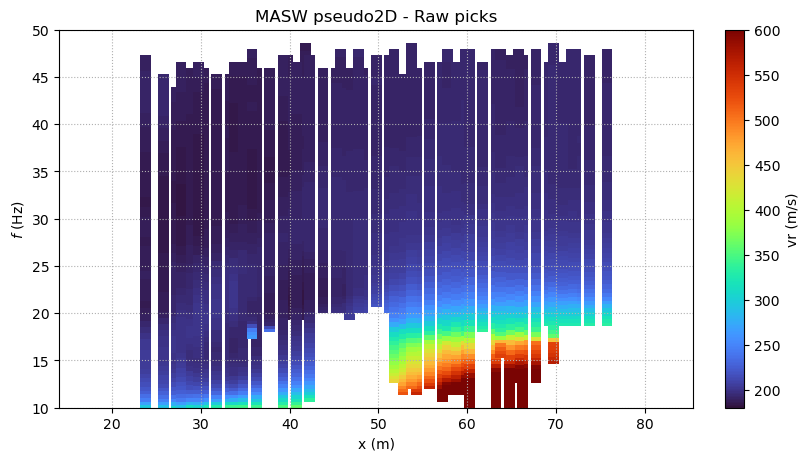

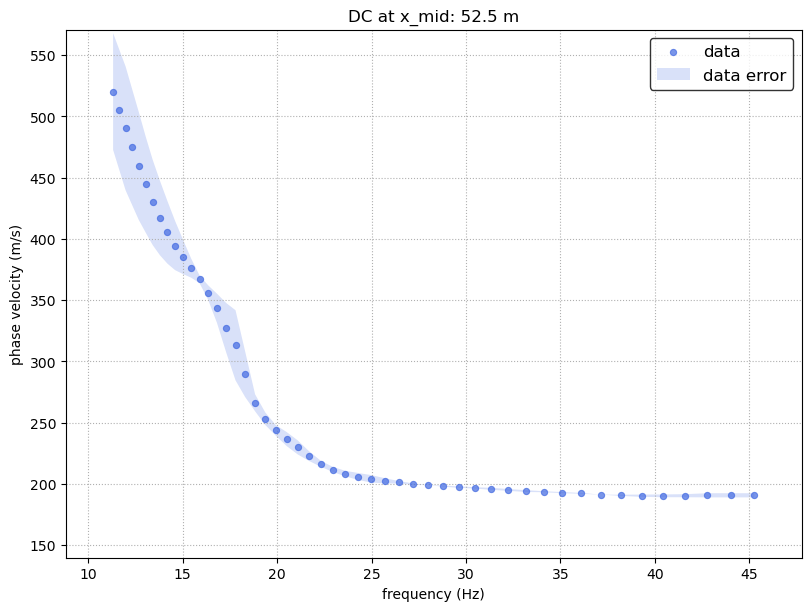

In [19]:
# %% combine dispersion curves
combCurves = CombineCurves(prjdir=path2disp,        # location where dcs are stored
                           path2cmb = path2cmb)     # location where combined dcs shall be stored

# import the data located in path2disp
combCurves._import_data()

# interactive filtering of data
#combCurves._filter_all()

# combine all dispersion curves with same xmid
combCurves._combine_all(mode=1,
                        a= 8,
                        kind = 'linear',
                        pn=50,            # parameter controlling the wavelength interval
                        save=True,      # save the combined dc
                        show=False)     # show the combined dc

# read the dispersion curve data and plot the 2D pseudosection
path2csv = '0_csv'
dcs = [f.path for f in os.scandir(os.path.join(path2cmb,path2csv))]

vmin = 180
vmax = 600

fig,ax = plt.subplots(figsize=(8,4.5), constrained_layout = True)

for i,fname_dc in enumerate(dcs):

    _, sf = os.path.split(fname_dc)
    xmid = float(re.findall(r"[-+]?(?:\d*\.*\d+)", sf)[0])

    curve = Curve()
    curve._read(fname_dc)
    curve._plotColumn(axes = ax,
                  xmid = xmid,
                  vmin = vmin, vmax = vmax,
                  cmap = 'turbo', y_value = 'f',
                  width = 0.3*sr_move,)


plot_colorBar(ax, vmin, vmax, cmap='turbo', orientation='vertical')
ax.set_xlim([receiver_coordinates[0,0],receiver_coordinates[-1,0]])
ax.set_ylim([fmin+5,fmax])

ax.set_title('MASW pseudo2D - Raw picks')
fig.savefig(os.path.join(path2plot,'2_masw2D.png'), dpi=200)
plt.show()

# plot a single dispersion curve and the error
_, sf = os.path.split(dcs[25])
xmid = float(re.findall(r"[-+]?(?:\d*\.*\d+)", sf)[0])
curve = Curve()
curve._read(dcs[0])
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
curve._plotdata(axes=ax)
plt.title('DC at x_mid: 52.5 m')
#fig.savefig(os.path.join(path2plot,'dc.png'))
plt.show()
